In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False) # 抗生素欄位清單

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [9]:
data_filter.head(6)

,ACCOUNTNO,INFECTIONSITE1,INFECTIONSITE2,INFECTIONSITE3,INFECTIONSITE4,INFECTIONSITE5,INFECTIONSITE9,OTHERINFECTIONSITE_flag,ROOMNO,AGE,SEX,StayTime_hours,INTIME,ISSEPSIS0,VITALSIGNSBT,VITALSIGNSPR,VITALSIGNSRR,VITALSIGNSSPO2,VITALSIGNSDBP,VITALSIGNSGCS,MAP,FEVER,INJURELEVEL,DM,CARDIOVASCULAR,RESPIRATORY,CNS,CANCER,LIVER,KIDNEY,AUTOIMMUNE,Hb,WBC,Ht,PLT,Lymphocyte,Neutrophil Seg.,Absolute Neutrophil count,Na,K,Creatinine,GPT,CRP,HST,Leukocyte level,Nitrite level,Bacteria level,Microscopic RBC level,Microscopic WBC level,PH,Influenza Virus A level,T.Bilirubin,PT,INR,APTT,PCO2,HCO3,BE(ecf),O2 SAT,FIRST_ORDERTIME,CHECKITEM28A,CHECKITEM27,CHECKITEM27SCORE,CHECKITEM28SCORE,CHECKITEM29SCORE,CHECKITEM30SCORE,CHECKITEM31SCORE,CHECKITEM32SCORE,Amoxicillin/Clavulanic acid,Ampicillin,Azithromycin,Baloxavir marboxil,Cefadroxil,Cefazolin,Cefixime,Cefoperazone/sulbactam,Ceftriaxone,Cefuroxime,Cephalexin,Ciprofloxacin,Clindamycin,Flomoxef,Gentamicin,Levofloxacin,Metronidazole,Oseltamivir,Peramivir,Piperacillin/Tazobactam,Miss_INFECTSITE_flag
0,I11300000002,1,0,0,0,0,0,0,A,65.0,M,0.261944,2024-01-01 00:47:17,N,38.2,106.0,20.0,95.0,93.0,15.0,113.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,12.5,11.86,34.1,178.0,6.1,86.4,10247.0,137.0,3.3,1.20,50.0,14.768,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,I11300000003,0,0,0,0,0,0,0,C,48.0,F,0.460833,2024-01-01 00:50:21,N,36.4,88.0,20.0,NaN,85.0,15.0,105.0,Y,4.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,I11300000008,0,0,0,0,0,0,0,A,19.0,F,2.628056,2024-01-01 01:17:19,N,37.6,120.0,18.0,NaN,62.0,15.0,73.0,Y,3.0,N,N,N,N,N,N,N,N,11.4,7.32,34.6,194.0,19.6,68.6,5234.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,1.0,2.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,I11300000011,0,0,0,0,0,0,0,A,16.0,M,3.546944,2024-01-01 01:25:11,N,36.3,118.0,18.0,NaN,64.0,15.0,77.0,Y,3.0,N,N,Y,N,N,Y,Y,Y,17.4,16.01,48.2,300.0,8.1,84.4,13512.0,136.0,3.6,0.78,19.0,0.929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,I11300000014,0,0,0,0,0,0,0,A,22.0,F,2.638056,2024-01-01 03:03:43,N,36.9,103.0,18.0,NaN,61.0,15.0,74.0,Y,3.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
5,I11300000015,0,0,1,1,0,0,0,C,35.0,M,4.690278,2024-01-01 03:23:35,N,36.2,49.0,18.0,NaN,59.0,3.0,88.0,Y,1.0,N,N,N,N,N,N,N,N,13.9,17.59,41.0,184.0,4.7,87.6,16411.0,147.0,4.1,1.16,49.0,16.780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.6,1.05,28.0,60.0,23.9,-1.6,99.8,2024-01-01 03:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols] # 特徵欄位
y = data_filter[final_cols] # 藥物欄位

In [13]:
X.shape, y.shape

((27968, 69), (27968, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")


原本樣本數: 27968
過濾後樣本數: 22509
已刪除 5459 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['GPT', 'CHECKITEM29SCORE', 'VITALSIGNSGCS', 'INJURELEVEL',
       'VITALSIGNSSPO2', 'LIVER', 'AGE', 'Hb', 'CHECKITEM27',
       'CHECKITEM31SCORE', 'CHECKITEM30SCORE', 'INFECTIONSITE1', 'HCO3', 'CNS',
       'Creatinine', 'HST', 'CANCER', 'Miss_INFECTSITE_flag',
       'CHECKITEM27SCORE', 'PLT', 'Nitrite level', 'MAP', 'APTT', 'Ht',
       'VITALSIGNSBT', 'Na', 'PT', 'K', 'T.Bilirubin', 'VITALSIGNSRR',
       'Microscopic WBC level', 'FEVER', 'AUTOIMMUNE',
       'Absolute Neutrophil count', 'KIDNEY', 'CHECKITEM28SCORE',
       'Bacteria level', 'Leukocyte level', 'BE(ecf)', 'WBC',
       'OTHERINFECTIONSITE_flag', 'PH', 'PCO2', 'Lymphocyte', 'O2 SAT',
       'INFECTIONSITE5', 'CARDIOVASCULAR', 'INFECTIONSITE9', 'RESPIRATORY',
       'Microscopic RBC level', 'CHECKITEM32SCORE', 'VITALSIGNSPR',
       'StayTime_hours', 'INFECTIONSITE4', 'SEX', 'VITALSIGNSDBP',
       'INFECTIONSITE2', 'CRP', 'CHECKITEM28A', 'INFECTIONSITE3', 'INR', 'DM',
       'Neutrophil Seg.'],
      dtype='ob

In [17]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


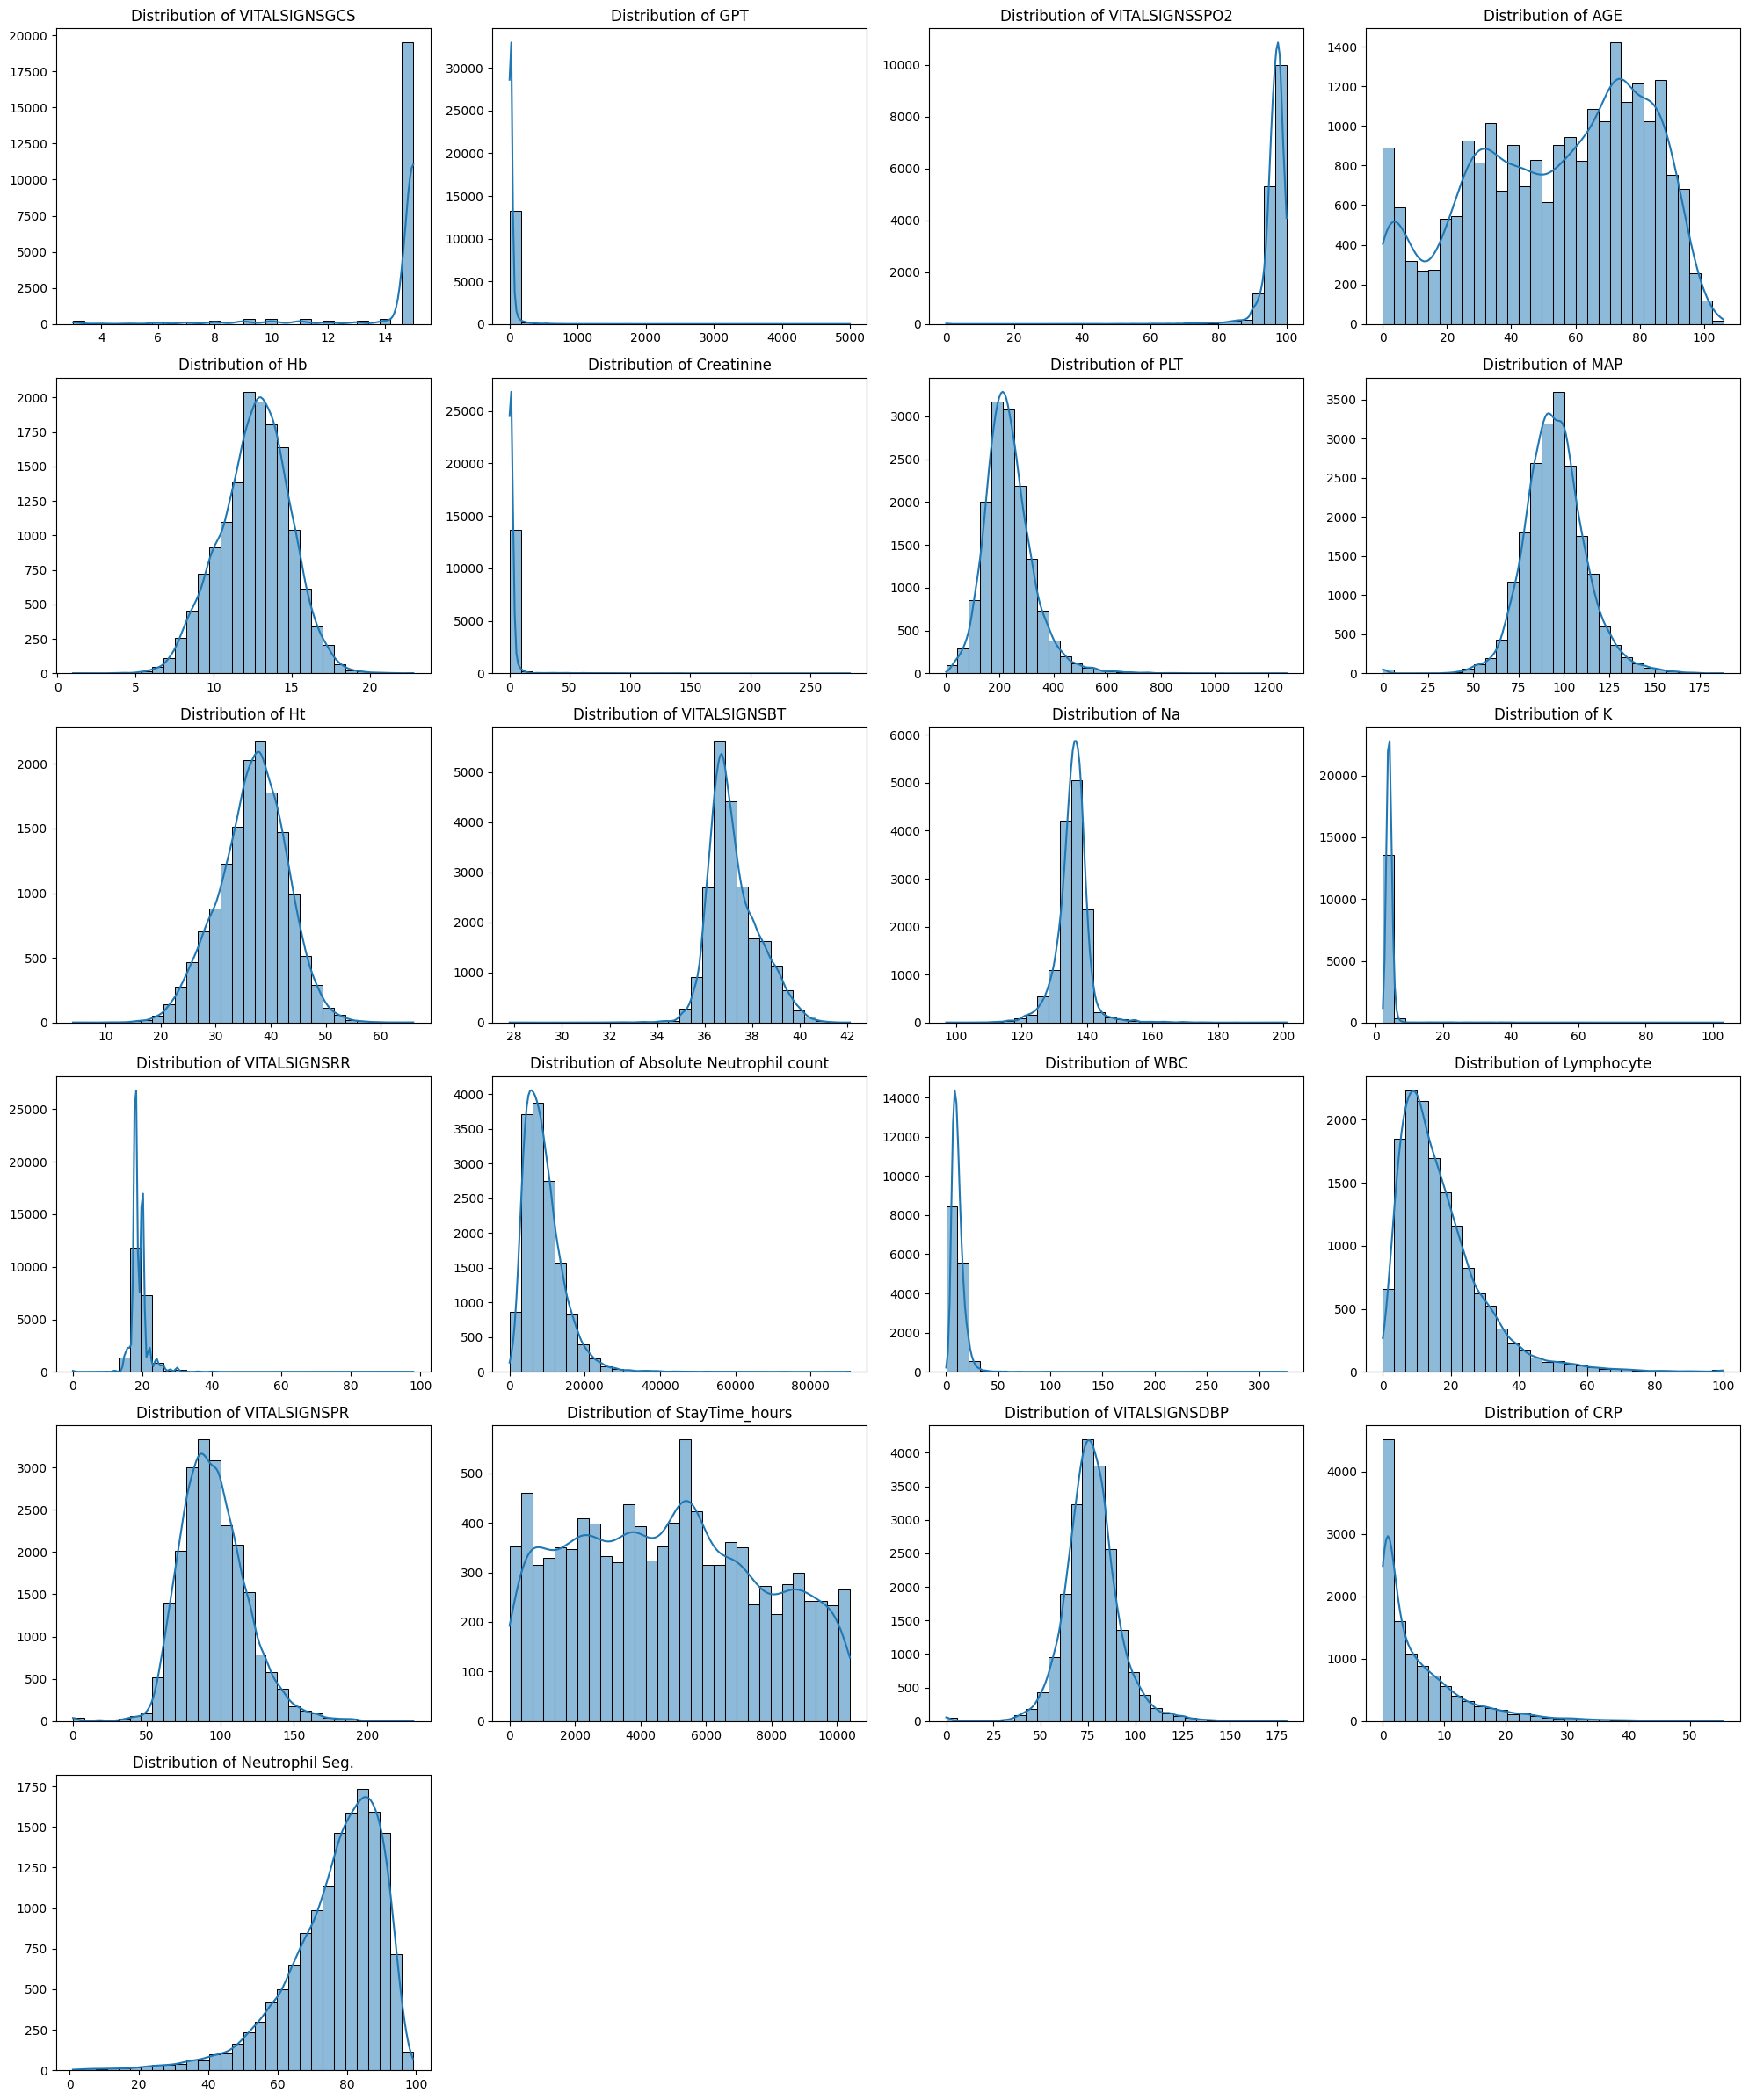

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 6941

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              201                   202   
VITALSIGNSBT                              190                   196   
MAP                                       200                   185   
VITALSIGNSDBP                             188                   190   
VITALSIGNSRR                              109                   216   
WBC                                       147                   147   
PLT                                       144                   147   
Absolute Neutrophil count                 145                   145   
Neutrophil Seg.                           144                   144   
Ht                                        143                   144   

                           Total_Outliers  
VITALSIGNSPR                          403  
VITALSIGNSBT                          386  
MAP                                   385  
VITAL

In [20]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((18007, 86), (18007, 15), (4502, 86), (4502, 15))

In [22]:
X_train.isnull().sum(), X_test.isnull().sum()

(GPT                       7051
 CHECKITEM29SCORE         13840
 VITALSIGNSGCS              282
 INJURELEVEL                  0
 VITALSIGNSSPO2            4370
                          ...  
 CHECKITEM27_flag             0
 CHECKITEM27SCORE_flag        0
 CHECKITEM28SCORE_flag        0
 CHECKITEM31SCORE_flag        0
 CHECKITEM32SCORE_flag        0
 Length: 86, dtype: int64,
 GPT                      1783
 CHECKITEM29SCORE         3459
 VITALSIGNSGCS              70
 INJURELEVEL                 0
 VITALSIGNSSPO2           1082
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 86, dtype: int64)

In [23]:
X_train.dtypes, X_test.dtypes

(GPT                      float64
 CHECKITEM29SCORE         float64
 VITALSIGNSGCS            float64
 INJURELEVEL              float64
 VITALSIGNSSPO2           float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 86, dtype: object,
 GPT                      float64
 CHECKITEM29SCORE         float64
 VITALSIGNSGCS            float64
 INJURELEVEL              float64
 VITALSIGNSSPO2           float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 86, dtype: object)

In [24]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4375.0
Flomoxef                       4171.0
Cefazolin                      1912.0
Cefixime                       1737.0
Ciprofloxacin                  1685.0
Azithromycin                   1650.0
Cefuroxime                     1348.0
Piperacillin/Tazobactam        1195.0
Cefoperazone/sulbactam         1129.0
Metronidazole                   801.0
Levofloxacin                    565.0
Gentamicin                      509.0
Clindamycin                     503.0
Ceftriaxone                     468.0
Ampicillin                      350.0
dtype: float64

In [25]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [26]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [27]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [28]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [29]:
y_train.sum(axis=1).mean() # 每人平均用1.24個抗生素

np.float64(1.2438496140389848)

In [30]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [31]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [32]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(18007, 63)

In [33]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [34]:
X_train.columns

Index(['GPT', 'VITALSIGNSGCS', 'INJURELEVEL', 'VITALSIGNSSPO2', 'LIVER', 'AGE',
       'Hb', 'INFECTIONSITE1', 'CNS', 'Creatinine', 'CANCER',
       'Miss_INFECTSITE_flag', 'PLT', 'MAP', 'Ht', 'VITALSIGNSBT', 'Na', 'K',
       'VITALSIGNSRR', 'FEVER', 'AUTOIMMUNE', 'Absolute Neutrophil count',
       'KIDNEY', 'WBC', 'OTHERINFECTIONSITE_flag', 'Lymphocyte',
       'INFECTIONSITE5', 'CARDIOVASCULAR', 'INFECTIONSITE9', 'RESPIRATORY',
       'VITALSIGNSPR', 'StayTime_hours', 'INFECTIONSITE4', 'SEX',
       'VITALSIGNSDBP', 'INFECTIONSITE2', 'CRP', 'INFECTIONSITE3', 'DM',
       'Neutrophil Seg.', 'Leukocyte level_flag', 'Nitrite level_flag',
       'Bacteria level_flag', 'Microscopic RBC level_flag',
       'Microscopic WBC level_flag', 'PH_flag', 'CHECKITEM29SCORE_flag',
       'CHECKITEM30SCORE_flag', 'HST_flag', 'T.Bilirubin_flag', 'PT_flag',
       'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
       'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag',
       '

In [35]:
# LogisticRegressionCV?
# XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

In [36]:
base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )


multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

#################################################################################################

# # 用字典存所有的子模型
# models = {}

# for col in y_train.columns:
#     # 針對每一種抗生素動態計算比例
#     pos = y_train[col].sum()
#     neg = len(y_train) - pos
#     spw = neg / pos if pos > 0 else 1
    
#     # 為該藥物建立專屬模型
#     model = XGBClassifier(
#                            n_estimators=300,
#                            max_depth=5,
#                            learning_rate=0.05,
#                            subsample=0.8,
#                            colsample_bytree=0.8,
#                            eval_metric='logloss',
#                            gamma=0,
#                            reg_alpha=2.0,
#                            reg_lambda=0.0,
#                            min_child_weight=1,
#                            scale_pos_weight=spw,
#                            random_state =123,
#                            n_jobs=-1
#     )
    
#     print(f"正在訓練 {col}, scale_pos_weight: {spw:.2f}")
#     model.fit(X_train, y_train[col])
#     models[col] = model

# # 預測時手動合併
# y_prob_list = np.column_stack([models[col].predict_proba(X_test)[:, 1] for col in y_train.columns])

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=0,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=300, n_jobs=-1,
                                              num_parallel_tree=None,
                                              random_state=123, ...))

In [37]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.7389663727145745
0.7591628034203173


In [38]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
drug_weight = []

for i, col in enumerate(y_train.columns):
    # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    drug_weight.append(score)
drug_weight = np.clip(drug_weight, 1e-6, None)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.01 # penalty
belta = 0.9

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = (np.log(y_prob_list)+ beta * np.log(drug_weight)- alpha * np.log(drug_freq))
adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)

# 用adjusted_scores排序
topk_idx = np.argsort(adjusted_scores, axis=1)[:, -3:]

In [39]:
drug_weight

array([0.76950587, 0.71855933, 1.02241752, 0.81945679, 1.49698912,
       0.88154925, 1.01940241, 1.41007625, 1.31568607, 1.06322433,
       0.72860258, 0.79401021, 1.18030947, 0.86708629, 0.91312452])

In [40]:
drug_weight ** belta

array([0.78993388, 0.74270503, 1.02015333, 0.83593681, 1.43779437,
       0.89273368, 1.01744535, 1.36244299, 1.28007982, 1.05672605,
       0.7520412 , 0.81253762, 1.16090398, 0.879541  , 0.9214611 ])

In [41]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5221955342051419
0.40451193658069035


In [42]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

np.float64(0.46132829853398494)

In [43]:
hamming_loss(y_test, y_pred)

0.0795350214719384

In [44]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

k=5
hit3 = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hit3}")
precision3 = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precision3}")
recall_3 = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_3}")
map_3 = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_3}")

Hit@5: 0.9264771212794314
precision@5: 0.22025766326078458
Recall@5: 0.8969569080408707
MAP@5: 0.6510877881435411


In [45]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=k)

實際給藥: ['Levofloxacin']

推薦藥物:
1. Levofloxacin (Score: 0.5960)
2. Flomoxef (Score: 0.5067)
3. Cefoperazone/sulbactam (Score: 0.3947)
4. Piperacillin/Tazobactam (Score: 0.3757)
5. Azithromycin (Score: 0.3437)
實際給藥: ['Ciprofloxacin']

推薦藥物:
1. Flomoxef (Score: 0.6871)
2. Cefixime (Score: 0.4799)
3. Ciprofloxacin (Score: 0.3624)
4. Metronidazole (Score: 0.3055)
5. Ceftriaxone (Score: 0.1566)
實際給藥: ['Amoxicillin/Clavulanic acid']

推薦藥物:
1. Azithromycin (Score: 0.6589)
2. Amoxicillin/Clavulanic acid (Score: 0.4981)
3. Cefixime (Score: 0.2782)
4. Ciprofloxacin (Score: 0.1993)
5. Levofloxacin (Score: 0.1570)
實際給藥: ['Amoxicillin/Clavulanic acid']

推薦藥物:
1. Azithromycin (Score: 0.7364)
2. Amoxicillin/Clavulanic acid (Score: 0.5690)
3. Ciprofloxacin (Score: 0.4530)
4. Cefixime (Score: 0.3613)
5. Cefuroxime (Score: 0.1719)
實際給藥: ['Cefazolin', 'Gentamicin']

推薦藥物:
1. Cefazolin (Score: 0.7675)
2. Gentamicin (Score: 0.4278)
3. Amoxicillin/Clavulanic acid (Score: 0.1091)
4. Ciprofloxacin (Score: 0.071

In [46]:
y_test.head(6)

,Amoxicillin/Clavulanic acid,Ampicillin,Azithromycin,Cefazolin,Cefixime,Cefoperazone/sulbactam,Ceftriaxone,Cefuroxime,Ciprofloxacin,Clindamycin,Flomoxef,Gentamicin,Levofloxacin,Metronidazole,Piperacillin/Tazobactam
5286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2279,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17661,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
16914,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
